# Transfer Learning with Tensorflow : Fine Tuning 

In [1]:
# Check if we're using a GPU 
!nvidia-smi

Thu Feb 26 17:53:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-02-26 17:53:42--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-02-26 17:53:42 (145 MB/s) - ‘helper_functions.py’ saved [10246/10246]



## Get some data 

link : https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

In [3]:
# Import helper functions 
from helper_functions import create_tensorboard_callback , plot_loss_curves , unzip_data , walk_through_dir

In [4]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

unzip_data("10_food_classes_10_percent.zip")

--2026-02-26 17:53:51--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.98.207, 74.125.135.207, 142.251.188.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   240MB/s    in 0.7s    

2026-02-26 17:53:52 (240 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [5]:
# Check out how many images and subdirectories are in our dataset 
walk_through_dir("10_food_classes_10_percent")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/c

In [6]:
# Create training and test directories paths 
train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

In [7]:
import tensorflow as tf

IMG_SIZE = (244, 244)
BATCH_DATA = 32

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical",
                                                                            batch_size=BATCH_DATA)

test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                image_size=IMG_SIZE,
                                                                label_mode="categorical",
                                                                batch_size=BATCH_DATA)


Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [8]:
train_data_10_percent

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 244, 244, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

In [9]:
# Check class names of our dataset 
train_data_10_percent.class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [10]:
# See an example of a batch 
for images , labels in train_data_10_percent.take(1) :
    print(images , labels)

tf.Tensor(
[[[[108.09836    110.09836    125.09836   ]
   [109.64754    111.64754    126.64754   ]
   [109.70492    111.70492    126.70492   ]
   ...
   [137.64754    128.78706    129.3685    ]
   [138.19672    129.39026    129.80965   ]
   [137.19672    128.44429    128.70157   ]]

  [[113.29508    112.29508    128.29507   ]
   [112.45647    111.45647    127.45647   ]
   [108.86066    107.86066    123.86066   ]
   ...
   [146.49176    138.65628    135.42564   ]
   [148.2377     140.46591    137.00954   ]
   [149.2377     141.52962    137.84744   ]]

  [[116.336266   115.336266   131.33627   ]
   [114.35246    113.35246    129.35246   ]
   [108.7623     107.7623     123.7623    ]
   ...
   [153.49176    146.49176    138.49184   ]
   [154.58134    147.58134    139.38472   ]
   [154.7459     147.7459     139.3525    ]]

  ...

  [[ 79.59035     50.590343    81.59035   ]
   [ 78.516975    48.51697     82.516975  ]
   [ 78.2541      46.254097    85.2541    ]
   ...
   [ 55.443573    28.443

## Model 0 : Building a transfer learning model using the Keras Functional API

The sequential API is straight-forward , it runs our layers in sequential order .

In [11]:
# Create the base model with tf.keras.applications 

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False
)

# Freez the base model (so the underlying pre-trained patterns aren't updated during training)
base_model.trainable = False

# Create the inputs into our model
inputs = tf.keras.layers.Input(shape=(244, 244, 3) , name="input_layer")

# Normalize the inputs 
# x = tf.keras.layers.experimental.preprocessing.Rescaling(1/255.)(inputs)

# Pass the inputs to the base model 
x = base_model(inputs)

print(f"Shape after passing inputs through base model : {x.shape}")

# Average pool the outputs of the base model (aggregate the most importantt features)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
print(f"Shape after global average pooling 2D : {x.shape}")

# Create the output activation layer 
outputs = tf.keras.layers.Dense(10 , activation="softmax" , name="output_layer")(x)

# Combine the inputs with the outputs into a model
model_0 = tf.keras.Model(inputs , outputs)

# Compile the model
model_0.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])   

# Fit the model 
history_10_percent = model_0.fit(train_data_10_percent,
                                  epochs=5,
                                  steps_per_epoch=len(train_data_10_percent),
                                  validation_data=test_data,
                                  validation_steps=len(test_data),
                                  callbacks=[create_tensorboard_callback(dir_name="transfer_learning",
                                  experiment_name="10_percent_data")])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape after passing inputs through base model : (None, 7, 7, 1280)
Shape after global average pooling 2D : (None, 1280)
Saving TensorBoard log files to: transfer_learning/10_percent_data/20260226-175401
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.2677 - loss: 2.0934 - val_accuracy: 0.7420 - val_loss: 1.2760
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step - accuracy: 0.7924 - loss: 1.1392 - val_accuracy: 0.8284 - val_loss: 0.8367
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.8365 - loss: 0.7891 - val_accuracy: 0.8508 - val_loss: 0.6705
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 273ms/step - accuracy: 0.8705 - loss: 0.6356 - val_accuracy: 0.8628 - val_loss: 0.5847
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 225ms/step - accuracy: 0.8888 - loss: 0.5218 - val_accuracy: 0.8700 - val_loss: 0.5367


In [12]:
model_0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

In [13]:
# Evaluate on the full test dataset 
model_0.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8747 - loss: 0.5205


[0.5366817116737366, 0.8700000047683716]

In [14]:
# Check the layers in our base model
for layers in base_model.layers : 
    print(layers.name)

input_layer
rescaling
normalization
rescaling_1
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_squeeze
block3a_se_reshape
block3a_se_reduce
block3a_se_expand

In [15]:
# How about to get a summary of the base model layers ? 

base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
# Whole model summary
model_0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

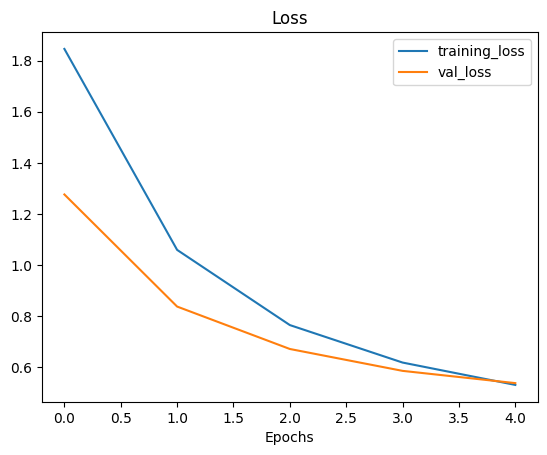

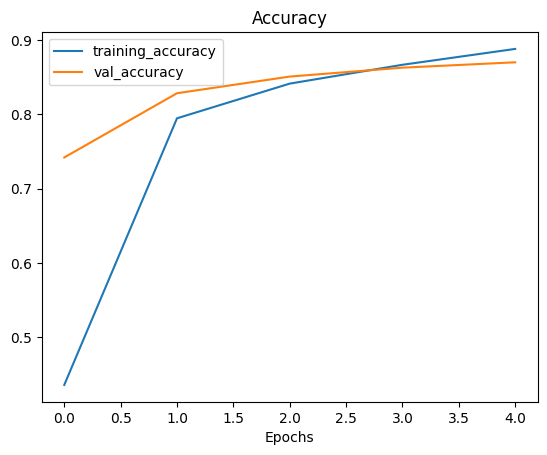

In [18]:
# Check out our model's training curves 
plot_loss_curves(history_10_percent)

## Getting a feature vector from a trained model 

Let's demonstrate the Global Average Pooling 2D layer ...

We have a tensor after our model goes through `base_model` of shape (None , 7 , 7 , 1280)...

But then when it passes through GlobalAveragePooling 2D  , it turns into (None , 1280) .

Let's use a similar shaped tensor of (1,4,4,3) and then pass it to GlobalAveragePooling2D .


In [20]:
# Define the input shape 
input_shape = (1 , 4, 4, 3)

# Create a random tensor 
tf.random.set_seed(42)
input_tensor = tf.random.normal(input_shape)
print(f"Random input tensor : \n {input_tensor}\n")

Random input tensor : 
 [[[[ 0.3274685  -0.8426258   0.3194337 ]
   [-1.4075519  -2.3880599  -1.0392479 ]
   [-0.5573232   0.539707    1.6994323 ]
   [ 0.28893656 -1.5066116  -0.2645474 ]]

  [[-0.59722406 -1.9171132  -0.62044144]
   [ 0.8504023  -0.40604794 -3.0258412 ]
   [ 0.9058464   0.29855987 -0.22561555]
   [-0.7616443  -1.8917141  -0.93847126]]

  [[ 0.77852213 -0.47338894  0.97772694]
   [ 0.24694404  0.20573746 -0.52562326]
   [ 0.32410017  0.02545409 -0.10638496]
   [-0.63694745  1.1603122   0.2507359 ]]

  [[-0.41728503  0.4012578  -1.4145443 ]
   [-0.5931857  -1.6617213   0.33567193]
   [ 0.10815628  0.23479679 -0.56668764]
   [-0.35819843  0.88698614  0.52744764]]]]



In [21]:
# Pass the random tensor throught a global average pooling 2D layer
global_average_pooled_tensor = tf.keras.layers.GlobalAveragePooling2D()(input_tensor) 

In [22]:
print(f"2D global average pooled random tensor : \n {global_average_pooled_tensor}")

2D global average pooled random tensor : 
 [[-0.09368646 -0.45840448 -0.2885598 ]]


In [23]:
# Check the shape of the different tensors 
print(f"Shape of input tensor : {input_tensor.shape}")
print(f"Shape of Global Average Pooled 2D tensor : {global_average_pooled_tensor.shape}")

Shape of input tensor : (1, 4, 4, 3)
Shape of Global Average Pooled 2D tensor : (1, 3)


In [24]:
# Let's replicate the GlobalAveragePool2D layer 
tf.reduce_mean(input_tensor , axis=[1,2])

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[-0.09368646, -0.45840448, -0.2885598 ]], dtype=float32)>

## Running a series of transfer learning experiments 

We've seen the incredible results transfer learning can get with only 10% of the training data , but how does it go with 1% of the training data ... how about we set up a bunch of experiments to find out :

1. `model_1` - use feature extraction transfer learning with 1% of the training data with data augumentation 
2. `model_2` - use feature extraction transfer learning with 10% of the training with data augumentation
3. `model_3` - use fine-tuning transfer learning on 10% of the training data with data augumentation 
4. `model_4` - use fine-tuning transfer learning on 100% of the training data with data augumentation 

🔑 **Note** : throught all experiments the same test dataset will be used to evaluate our model .. this ensures consistency across evaluation metrics . 

In [25]:
# Download and unzip data - FOOD101 preprocessed
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip

unzip_data("10_food_classes_1_percent.zip")

--2026-02-26 18:41:59--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.163.207, 173.194.202.207, 173.194.203.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.163.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133612354 (127M) [application/zip]
Saving to: ‘10_food_classes_1_percent.zip’

10_food_classes_1_p 100%[===================>] 127.42M   148MB/s    in 0.9s    

2026-02-26 18:42:00 (148 MB/s) - ‘10_food_classes_1_percent.zip’ saved [133612354/133612354]



In [26]:
# Create training and test dirs 
train_dir_1_percent = "10_food_classes_1_percent/train"
test_dir = "10_food_classes_1_percent/test"

In [27]:
# How many images are we working with 
walk_through_dir("10_food_classes_1_percent")

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/train'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_wings'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/sushi'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ramen'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/grilled_salmon'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/steak'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/hamburger'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/fried_rice'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/pizza'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ice_cream'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_curry'.
There a

In [28]:
# Setup data loaders 
IMG_SIZE = (244,244)
train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_1_percent,
                                                                           label_mode="categorical",
                                                                           image_size=IMG_SIZE,
                                                                           batch_size=32)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE,
                                                                batch_size=32)

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


## Adding data augumentation right into the model 

To add data augumentation right into our models , we can use the layers inside : 

* `tf.keras.layers.experimental.preprocessing()`

Data augumentation : https://www.tensorflow.org/guide/keras/preprocessing_layers

* Preprocessing of images (augumenting them) happens on the GPU (much faster) rather than the CPU
* Image data augumentation only happens during training , so we can still export our whole model and use it elsewhere 

In [64]:
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 

# Create data augumentation stage with horizontal flipping , rotations , zooms etc..
data_augumentation = keras.Sequential([
    layers.Resizing(244,244),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
    #layers.Rescale(1./255) # Keep from models like ResNet50V2 but EfficientNet's having rescaling built-in
] , name = "data_augumentation")

## Visualize our data augumentation layer (and see what happens to our data)

(np.float64(-0.5), np.float64(243.5), np.float64(243.5), np.float64(-0.5))

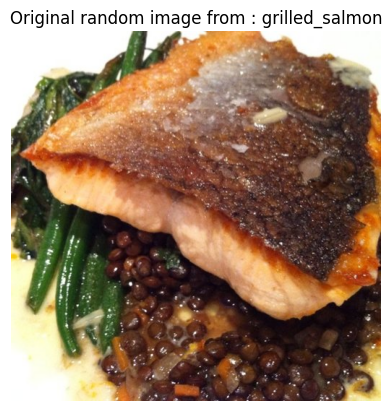

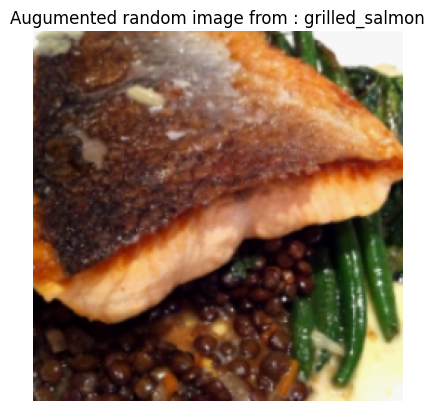

In [68]:
# View a random image and compare it to its augumented version 
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg 
import os 
import random 

target_class = random.choice(train_data_1_percent.class_names)
target_dir = "10_food_classes_1_percent/train/" + target_class 
random_image = random.choice(os.listdir(target_dir))
random_image_path = target_dir + "/" + random_image

# Read and plot in the random image 
img = mpimg.imread(random_image_path)
#print(img)
plt.imshow(img)
plt.title(f"Original random image from : {target_class}")
plt.axis(False)

# Now let's plot our augumented random image 
augumented_img = data_augumentation(img , training=True)
plt.figure()
plt.imshow(tf.squeeze(augumented_img)/255.)
plt.title(f"Augumented random image from : {target_class}")
plt.axis(False)

## Model 1 : Feature extraction transfer learning on 1% of the data with data augumentation 

In [70]:
data_aug = keras.Sequential([
    layers.Resizing(244,244),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
    #layers.Rescale(1./255) # Keep from models like ResNet50V2 but EfficientNet's having rescaling built-in
] , name = "data_augumentation_2")

In [71]:

# Setup input shape and base model , freezing the base model layers 
input_shape = (244,244,3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Create input layer 
inputs = layers.Input(shape=in_shape , name="input_layer")

# Add in data augumentation Sequential model as a layer
x = data_aug(inputs)

# Give base_model the inputs (after augumentation) and don't train it 
x = base_model(x , training=False)

# Pool output features of the base model 
x = layers.GlobalAveragePooling2D()(x)

# Put a dense layer on as the output 
outputs = layers.Dense(10 , activation="softmax" , name="output_layer")(x)

# Make a model using the inputs and outputs 
model_1 = keras.Model(inputs , outputs)

# Compile the model 
model_1.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model 
history_1_percent = model_1.fit(train_data_1_percent,
                                epochs=5,
                                steps_per_epoch=len(train_data_1_percent),
                                validation_data=test_data,
                                validation_steps=int(0.25 * len(test_data)),
                                # Track model training logs
                                callbacks=[create_tensorboard_callback(dir_name="transfer_learning" , experiment_name="1_percent_data_aug")])

Saving TensorBoard log files to: transfer_learning/1_percent_data_aug/20260226-200814
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.1866 - loss: 2.2239 - val_accuracy: 0.2599 - val_loss: 2.1408
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 885ms/step - accuracy: 0.3550 - loss: 1.9930 - val_accuracy: 0.3520 - val_loss: 2.0218
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 866ms/step - accuracy: 0.4890 - loss: 1.8155 - val_accuracy: 0.4013 - val_loss: 1.9124
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 868ms/step - accuracy: 0.5852 - loss: 1.6852 - val_accuracy: 0.4572 - val_loss: 1.8144
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 875ms/step - accuracy: 0.6235 - loss: 1.5265 - val_accuracy: 0.4852 - val_loss: 1.7283


In [72]:
# Check out a model summary 
model_1.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augumentation_2            │ (None, 244, 244, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

In [73]:
# Evaluate on the full test dataset 
results_1_percent_data_aug = model_1.evaluate(test_data)
results_1_percent_data_aug 

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.4922 - loss: 1.7305


[1.7234456539154053, 0.492000013589859]

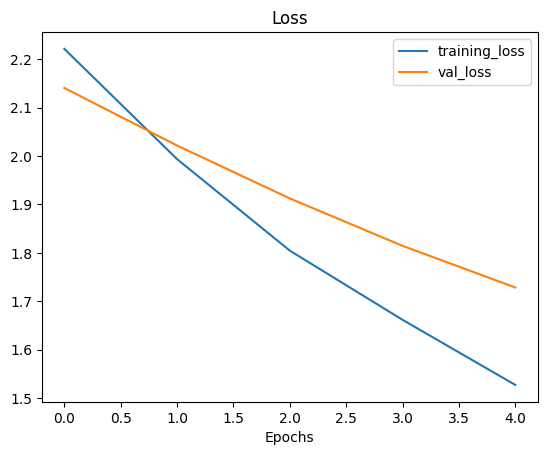

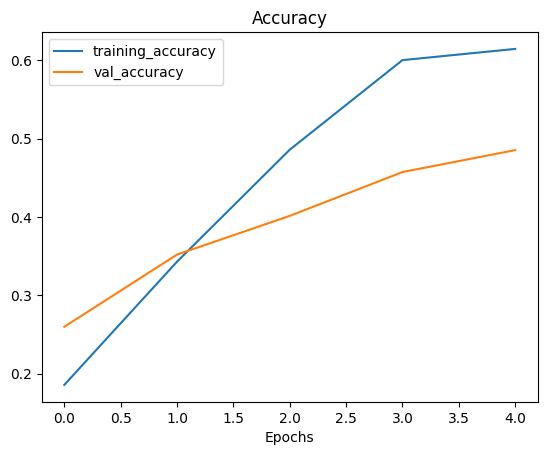

In [74]:
# How do the model with 1% of the data and data augumentation loss curves look ? 
plot_loss_curves(history_1_percent) 